# Model Training & Evaluation

6 models × random/temporal splits

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from logistics_delay.data.loader import load_processed
from logistics_delay.features.engineering import get_feature_lists
from logistics_delay.models.train import random_split, temporal_split
from logistics_delay.models.evaluate import evaluate, get_model, ALL_MODELS, _prepare_xgb_input
from logistics_delay.utils.paths import FIGURES_MODELS

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
print("[OK] 导入完成")

[OK] 导入完成


In [2]:
df = load_processed()
FEATURES_ENC, FEATURES_XGB, XGB_CAT_COLS = get_feature_lists()
X_enc = df[FEATURES_ENC]
X_xgb = df[FEATURES_XGB]
y = df['Answer']
print(f'Data shape: {df.shape}')
print(f'Delay rate: {y.mean()*100:.1f}%')

[loader] 预处理数据加载完成: (6854, 54)
[loader] 延误率: 63.19%
Data shape: (6854, 54)
Delay rate: 63.2%


In [3]:
# ── Random split ──
X_train_r, X_test_r, y_train_r, y_test_r, spw_r = random_split(df, "enc")
X_train_r_xgb = X_xgb.loc[X_train_r.index]
X_test_r_xgb = X_xgb.loc[X_test_r.index]

[train] 随机划分: 训练 5483 / 测试 1371
[train] scale_pos_weight = 0.5824


In [4]:
# ── Temporal split ──
X_train_t, X_test_t, y_train_t, y_test_t, spw_t, cutoff = temporal_split(df, "enc")
X_train_t_xgb = FEATURES_XGB and df.sort_values('trip_start_date').reset_index(drop=True).loc[:int(len(df)*0.8)-1, FEATURES_XGB].reset_index(drop=True)
X_test_t_xgb = FEATURES_XGB and df.sort_values('trip_start_date').reset_index(drop=True).loc[int(len(df)*0.8):, FEATURES_XGB].reset_index(drop=True)

[train] 时序划分: 分割点 2020-08-08
[train] 训练: 5483 条, 2019-03-18 ~ 2020-08-08
[train] 测试: 1371 条, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818


In [5]:
# ── Train & evaluate all models ──
def run(models, X_tr_e, X_te_e, X_tr_x, X_te_x, y_tr, y_te, spw, label):
    results = []
    for mn in models:
        X_tr = _prepare_xgb_input(mn, X_tr_e, X_tr_x)
        X_te = _prepare_xgb_input(mn, X_te_e, X_te_x)
        cat_feats = XGB_CAT_COLS if mn == 'CatBoost' else None
        m = get_model(mn, spw, cat_features=cat_feats)
        if mn == 'LightGBM':
            m.fit(X_tr, y_tr, categorical_feature=XGB_CAT_COLS)
        else:
            m.fit(X_tr, y_tr)
        res = evaluate(m, X_te, y_te, mn)
        res['auc_pct'] = round(res['auc'] * 100, 2)
        results.append(res)
        print(f"{mn:<20s}  {label}  AUC={res['auc_pct']:.2f}%  F1={res['f1']:.4f}")
    return pd.DataFrame(results)

models = ['LogisticRegression','DecisionTree','RandomForest','XGBoost','CatBoost','LightGBM']
print("=== Random Split ===")
df_rand = run(models, X_train_r, X_test_r, X_train_r_xgb, X_test_r_xgb, y_train_r, y_test_r, spw_r, "random")
print("=== Temporal Split ===")
# Recompute temporal X matrices properly
df_sorted = df.sort_values('trip_start_date').reset_index(drop=True)
si = int(len(df_sorted) * 0.8)
X_tr_t_e = df_sorted.loc[:si-1, FEATURES_ENC].reset_index(drop=True)
X_te_t_e = df_sorted.loc[si:, FEATURES_ENC].reset_index(drop=True)
X_tr_t_x = df_sorted.loc[:si-1, FEATURES_XGB].reset_index(drop=True)
X_te_t_x = df_sorted.loc[si:, FEATURES_XGB].reset_index(drop=True)
y_tr_t = df_sorted.loc[:si-1, 'Answer'].reset_index(drop=True)
y_te_t = df_sorted.loc[si:, 'Answer'].reset_index(drop=True)
spw_t = len(y_tr_t[y_tr_t==0]) / len(y_tr_t[y_tr_t==1])
df_time = run(models, X_tr_t_e, X_te_t_e, X_tr_t_x, X_te_t_x, y_tr_t, y_te_t, spw_t, "temporal")
print("\n=== Summary ===")
print("随机划分和时序划分已训练完毕，存在数据泄露嫌疑，后续训练均以时序划分为主")

=== Random Split ===
LogisticRegression    random  AUC=93.76%  F1=0.8986
DecisionTree          random  AUC=96.41%  F1=0.9343
RandomForest          random  AUC=97.51%  F1=0.9440
XGBoost               random  AUC=98.00%  F1=0.9413
CatBoost              random  AUC=98.40%  F1=0.9543
LightGBM              random  AUC=98.25%  F1=0.9471
=== Temporal Split ===
LogisticRegression    temporal  AUC=91.56%  F1=0.7189
DecisionTree          temporal  AUC=39.46%  F1=0.3900
RandomForest          temporal  AUC=74.14%  F1=0.4285
XGBoost               temporal  AUC=61.67%  F1=0.3890
CatBoost              temporal  AUC=77.89%  F1=0.6036
LightGBM              temporal  AUC=68.47%  F1=0.4137

=== Summary ===
随机划分和时序划分已训练完毕，存在数据泄露嫌疑，后续训练均以时序划分为主


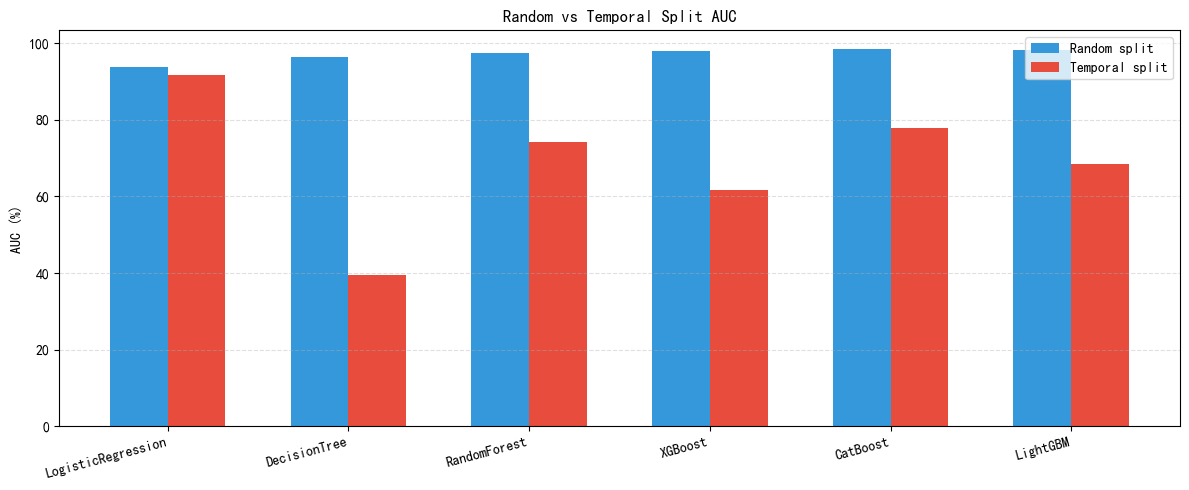

图片已保存到: C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\models\split_comparison_auc.png


In [6]:
# ── AUC comparison bar chart ──
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(models)); w = 0.32
r_aucs = df_rand['auc_pct'].values
t_aucs = df_time['auc_pct'].values
ax.bar(x - w/2, r_aucs, w, label='Random split', color='#3498db')
ax.bar(x + w/2, t_aucs, w, label='Temporal split', color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('AUC (%)'); ax.set_title('Random vs Temporal Split AUC')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_MODELS / "split_comparison_auc.png" , dpi=300 , bbox_inches='tight')
plt.show()
print("图片已保存到:", FIGURES_MODELS / "split_comparison_auc.png")

In [7]:
print(f"Best random: {df_rand.loc[df_rand['auc'].idxmax(), 'model']}  AUC={df_rand['auc'].max()*100:.2f}%")
print(f"Best temporal: {df_time.loc[df_time['auc'].idxmax(), 'model']}  AUC={df_time['auc'].max()*100:.2f}%")

Best random: CatBoost  AUC=98.40%
Best temporal: LogisticRegression  AUC=91.56%
